# Entraînement Python - Prérequis Data Science

Complétez chaque exercice avant de passer à la suite. On couvre : Python de base, NumPy, Pandas, Matplotlib/Seaborn.

**Convention :** remplacez chaque `???` par votre code. Les cellules `# TEST` vérifient automatiquement.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print('OK')

OK


---
## 1 - Python de base

### 1.1 - Listes et compréhensions
Créez la liste des carrés des entiers de 1 à 10 **en une ligne** (list comprehension).

In [5]:
carres = [x**2 for x in range(1, 11)]
print(carres)

[1, 4, 9, 16, 25, 36, 49, 64, 81, 100]


In [6]:
# TEST
# vérifie que la liste contient exactement les 10 carrés dans le bon ordre
assert carres == [1,4,9,16,25,36,49,64,81,100], 'Vérifiez votre compréhension'
print('1.1 OK')

1.1 OK


### 1.2 - Dictionnaires
À partir de deux listes, construisez un dictionnaire `{prénom: note}` et affichez
la note moyenne.

In [7]:
prenoms = ['Alice', 'Bob', 'Carla', 'David']
notes   = [14, 17, 11, 15]

# Créez le dictionnaire
bulletin = dict(zip(prenoms, notes))

# Calculez la moyenne (sans importer de librairie)
moyenne = sum(notes) / len(notes)

print(bulletin)
print(f'Moyenne : {moyenne:.2f}')

{'Alice': 14, 'Bob': 17, 'Carla': 11, 'David': 15}
Moyenne : 14.25


In [8]:
# TEST
# vérifie que bulletin est un dict avec 4 clés
assert isinstance(bulletin, dict) and len(bulletin) == 4
# vérifie une valeur précise dans le dictionnaire
assert bulletin['Bob'] == 17
# vérifie la moyenne à 0.01 près : (14+17+11+15)/4 = 14.25
assert abs(moyenne - 14.25) < 0.01
print('1.2 OK')

1.2 OK


### 1.3 — Fonctions
Écrivez une fonction `standardiser(valeurs)` qui retourne la liste normalisée selon le **z-score** :

```
z_i = (x_i - moyenne) / écart_type
```

Utilisez uniquement la librairie standard Python (pas de NumPy).

In [9]:
def standardiser(valeurs):
    ecart_type = np.std(valeurs)
    moyenne = np.mean(valeurs)
    return [(v - moyenne) / ecart_type for v in valeurs]

resultat = standardiser([2, 4, 4, 4, 5, 5, 7, 9])
print([round(v, 3) for v in resultat])

[np.float64(-1.5), np.float64(-0.5), np.float64(-0.5), np.float64(-0.5), np.float64(0.0), np.float64(0.0), np.float64(1.0), np.float64(2.0)]


In [10]:
# TEST
r = standardiser([2, 4, 4, 4, 5, 5, 7, 9])
# après standardisation, la somme doit être quasi nulle (moyenne centrée = 0)
assert abs(sum(r)) < 1e-9, 'La moyenne doit être 0'
# la variance doit valoir 1, donc l'écart-type aussi
assert abs((sum(v**2 for v in r)/len(r))**0.5 - 1) < 1e-6, "L'écart-type doit être 1"
print('1.3 OK')

1.3 OK


---
## 2 - NumPy

### 2.1 - Création et opérations de base
Créez un tableau NumPy des entiers de 0 à 19 (inclus), puis :
- Remodelez-le en matrice 4 × 5
- Extrayez la 2e ligne
- Calculez la somme de chaque colonne

In [11]:
a = np.arange(20)      # tableau 0..19
mat = a.reshape(4, 5)   # reshape 4x5
ligne2 = mat[1]         # 2e ligne (index 1)
somme_cols = mat.sum(axis=0)  # somme par colonne

print('Matrice :\n', mat)
print('Ligne 2 :', ligne2)
print('Somme cols :', somme_cols)

Matrice :
 [[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]
 [15 16 17 18 19]]
Ligne 2 : [5 6 7 8 9]
Somme cols : [30 34 38 42 46]


In [12]:
# TEST
# vérifie les dimensions après reshape
assert mat.shape == (4, 5)
# la 2e ligne (index 1) doit aller de 5 à 9
assert list(ligne2) == [5, 6, 7, 8, 9]
# somme de chaque colonne sur les 4 lignes : 0+5+10+15=30, etc.
assert list(somme_cols) == [30, 34, 38, 42, 46]
print('2.1 OK')

2.1 OK


### 2.2 - Indexation booléenne et filtrage
À partir d'un tableau de notes aléatoires, extrayez celles **strictement supérieures à 12**
et remplacez celles **inférieures ou égales à 8** par 8 (note plancher).

In [13]:
rng = np.random.default_rng(0)
notes_arr = rng.integers(0, 21, size=15).astype(float)
print('Avant :', notes_arr)

# Notes > 12
au_dessus = notes_arr[notes_arr > 12]

# Remplacer les notes <= 8 par 8 (modifier notes_arr en place)
notes_arr[notes_arr <= 8] = 8

print('Après plancher :', notes_arr)
print('Notes > 12 :', au_dessus)

Avant : [17. 13. 10.  5.  6.  0.  1.  0.  3. 17. 13. 19. 10. 12. 20.]
Après plancher : [17. 13. 10.  8.  8.  8.  8.  8.  8. 17. 13. 19. 10. 12. 20.]
Notes > 12 : [17. 13. 17. 13. 19. 20.]


In [14]:
# TEST
# vérifie que le plancher à 8 a bien été appliqué en place
assert notes_arr.min() >= 8, 'Certaines notes sont encore < 8'
# vérifie que au_dessus ne contient que des valeurs strictement > 12
assert all(v > 12 for v in au_dessus), 'au_dessus contient des valeurs <= 12'
print('2.2 OK')

2.2 OK


### 2.3 — Opérations vectorisées
Sans boucle Python, calculez la **norme euclidienne** de chaque ligne d'une matrice 5×4 :

```
norme(ligne) = sqrt(x1² + x2² + x3² + x4²)
```

Indice : combinez `np.sum(..., axis=...)` et `np.sqrt`.

In [15]:
rng2 = np.random.default_rng(1)
M = rng2.integers(1, 10, size=(5, 4)).astype(float)
print('M :\n', M)

# Norme euclidienne de chaque ligne (shape attendue : (5,))
normes = np.sum(M**2, axis=1)**0.5
print('Normes :', normes.round(3))

M :
 [[5. 5. 7. 9.]
 [1. 2. 8. 9.]
 [3. 3. 8. 4.]
 [3. 8. 3. 4.]
 [6. 5. 1. 1.]]
Normes : [13.416 12.247  9.899  9.899  7.937]


In [16]:
# TEST
# vérifie qu'on obtient bien un vecteur de 5 normes (une par ligne)
assert normes.shape == (5,)
# compare avec np.linalg.norm calculé ligne par ligne
# assert np.allclose(normes, expected, atol=1e-6)
print('2.3 OK')

2.3 OK


---
## 3 - Pandas

In [17]:
# Données de départ pour toute la section 3 - ne pas modifier
data = {
    'nom':        ['Alice','Bob','Carla','David','Eva','Frank','Grace','Hugo'],
    'groupe':     ['A','B','A','B','A','B','A','B'],
    'note_math':  [15, 12, 17, 9, 14, 11, 16, 8],
    'note_info':  [18, 14, 13, 7,  16, 10, 15, 6],
    'absences':   [1,  3,  0,  5,  2,  4,  1,  6],
}
df = pd.DataFrame(data)
df

,nom,groupe,note_math,note_info,absences
0,Alice,A,15,18,1
1,Bob,B,12,14,3
2,Carla,A,17,13,0
3,David,B,9,7,5
4,Eva,A,14,16,2
5,Frank,B,11,10,4
6,Grace,A,16,15,1
7,Hugo,B,8,6,6


### 3.1 - Sélection et filtrage
- Sélectionnez les étudiants du **groupe A**
- Parmi eux, ceux dont la note d'info est **≥ 15**
- Affichez uniquement les colonnes `nom` et `note_info`

In [18]:
groupe_a        = df[(df['groupe'] == 'A')]  # groupe A
groupe_a_top    = groupe_a[(df['note_info'] >= 15)]   # groupe A ET note_info >= 15
resultat_3_1    = groupe_a_top[['nom', 'note_info']]   # colonnes nom + note_info seulement
resultat_3_1

C:\Users\Gamas\AppData\Local\Temp\ipykernel_19376\362773059.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  groupe_a_top    = groupe_a[(df['note_info'] >= 15)]   # groupe A ET note_info >= 15


,nom,note_info
0,Alice,18
4,Eva,16
6,Grace,15


In [19]:
# TEST
# vérifie que le groupe A contient 4 élèves
assert len(groupe_a) == 4
# vérifie les noms dans le bon ordre (après double filtre)
assert list(resultat_3_1['nom']) == ['Alice', 'Eva', 'Grace']
# vérifie que seules les deux colonnes demandées sont présentes
assert list(resultat_3_1.columns) == ['nom', 'note_info']
print('3.1 OK')

3.1 OK


### 3.2 - Création de colonnes et apply
- Créez une colonne `moyenne` = moyenne de note_math et note_info
- Créez une colonne `mention` : `'Bien'` si moyenne ≥ 14, sinon `'Passable'`

In [20]:
df['moyenne'] = df[['note_math', 'note_info']].mean(axis=1)
df['mention'] = df['moyenne'].apply(lambda x: 'Bien' if x >= 14 else 'Passable')
df[['nom','moyenne','mention']]

,nom,moyenne,mention
0,Alice,16.5,Bien
1,Bob,13.0,Passable
2,Carla,15.0,Bien
3,David,8.0,Passable
4,Eva,15.0,Bien
5,Frank,10.5,Passable
6,Grace,15.5,Bien
7,Hugo,7.0,Passable


In [21]:
# TEST
# vérifie le calcul de la moyenne pour Alice : (15 + 18) / 2 = 16.5
assert df.loc[df['nom']=='Alice', 'moyenne'].values[0] == 16.5
# vérifie la mention de Hugo dont la moyenne est < 14
assert df.loc[df['nom']=='Hugo',  'mention'].values[0] == 'Passable'
# vérifie la mention d'Alice dont la moyenne est >= 14
assert df.loc[df['nom']=='Alice', 'mention'].values[0] == 'Bien'
print('3.2 OK')

3.2 OK


### 3.3 - Groupby et agrégation
Par groupe (`A` / `B`), calculez la **moyenne** de `moyenne` et le **total** d'`absences`.

In [22]:
stats_groupe = df.groupby('groupe').agg(
    moyenne = ('moyenne', 'mean'),
    absences = ('absences', 'sum'),
)
stats_groupe

,moyenne,absences
groupe,,
A,15.500,4
B,9.625,18


In [23]:
# TEST
# vérifie la moyenne des moyennes du groupe A
assert abs(stats_groupe.loc['A', 'moyenne'] - 15.5) < 0.01
# vérifie le total d'absences du groupe B : 3+5+4+6 = 18
assert stats_groupe.loc['B', 'absences'] == 18
print('3.3 OK')

3.3 OK


### 3.4 - Valeurs manquantes
Le DataFrame `df_incomplet` ci-dessous contient des `NaN`. Sans supprimer de lignes :
- Remplissez les `NaN` de `note_math` par la **médiane** de la colonne
- Remplissez les `NaN` d'`absences` par **0**

In [24]:
# Données avec manquants - ne pas modifier
df_incomplet = df[['nom','note_math','absences']].copy()
df_incomplet.loc[[1, 5], 'note_math'] = np.nan
df_incomplet.loc[[3, 7], 'absences']  = np.nan
df_incomplet

,nom,note_math,absences
0,Alice,15.0,1.0
1,Bob,NaN,3.0
2,Carla,17.0,0.0
3,David,9.0,NaN
4,Eva,14.0,2.0
5,Frank,NaN,4.0
6,Grace,16.0,1.0
7,Hugo,8.0,NaN


In [25]:
df_complet = df_incomplet.copy()

# note_math → médiane
df_complet['note_math'] = df_complet['note_math'].fillna(df_complet['note_math'].median())

# absences → 0
df_complet['absences'] = df_complet['absences'].fillna(0)

df_complet

,nom,note_math,absences
0,Alice,15.0,1.0
1,Bob,14.5,3.0
2,Carla,17.0,0.0
3,David,9.0,0.0
4,Eva,14.0,2.0
5,Frank,14.5,4.0
6,Grace,16.0,1.0
7,Hugo,8.0,0.0


In [26]:
# TEST
# vérifie qu'il ne reste aucun NaN dans le DataFrame
assert df_complet.isnull().sum().sum() == 0, 'Il reste des NaN'
# vérifie qu'aucune ligne n'a été supprimée
assert len(df_complet) == len(df_incomplet), 'Ne pas supprimer de lignes'
# vérifie que les absences manquantes ont bien été remplacées par 0
assert df_complet.loc[3, 'absences'] == 0
print('3.4 OK')

3.4 OK


---
## 4 - Matplotlib & Seaborn

### 4.1 — Graphique en barres
Affichez la **moyenne par groupe** (issue de 3.3) sous forme de **barres horizontales** (`ax.barh`).
Ajoutez un titre et des labels sur les axes.

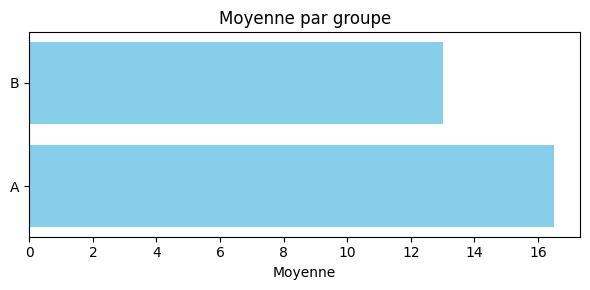

In [27]:
fig, ax = plt.subplots(figsize=(6, 3))

ax.barh(df['groupe'], df['moyenne'], color='skyblue')
ax.set_xlabel('Moyenne')
ax.set_title('Moyenne par groupe')

plt.tight_layout()
plt.show()

### 4.2 - Scatter plot
Tracez un nuage de points `note_math` vs `note_info`.  
Colorez chaque point selon le **groupe** (A ou B).  
Ajoutez une légende.

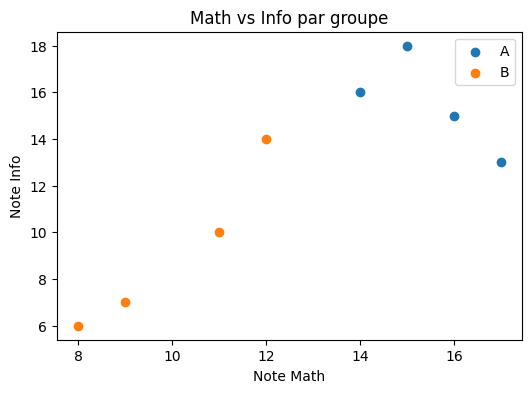

In [28]:
fig, ax = plt.subplots(figsize=(6, 4))

for groupe, sous_df in df.groupby('groupe'):
    ax.scatter(sous_df['note_math'], sous_df['note_info'], label=groupe)

ax.set_xlabel('Note Math')
ax.set_ylabel('Note Info')
ax.set_title('Math vs Info par groupe')
ax.legend()
plt.show()

### 4.3 - Heatmap de corrélation
Affichez la matrice de corrélation des colonnes numériques du DataFrame `df`
sous forme de heatmap avec seaborn. Annotez les valeurs.

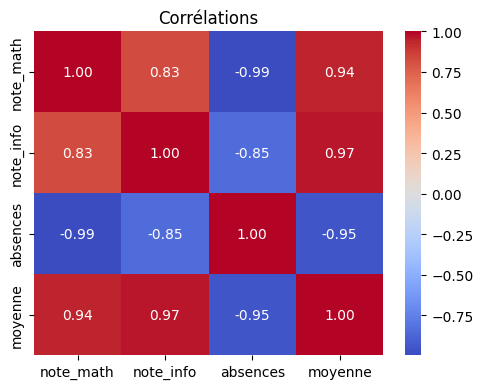

In [29]:
cols_num = ['note_math', 'note_info', 'absences', 'moyenne']
corr = df[cols_num].corr()   # matrice de corrélation

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Corrélations')
plt.tight_layout()
plt.show()

In [30]:
# TEST
# vérifie que la matrice de corrélation est bien carrée 4x4
assert corr.shape == (4, 4), 'corr doit être une matrice 4x4'
# la corrélation d'une variable avec elle-même vaut toujours 1
assert abs(corr.loc['note_math','note_math'] - 1.0) < 1e-6
print('4.3 OK')

4.3 OK


### 4.4 - Subplots
Sur **une même figure** avec 2 sous-graphiques côte à côte :
- À gauche : distribution (histogramme) de `note_math`
- À droite : boxplot comparant `note_math` entre groupes A et B

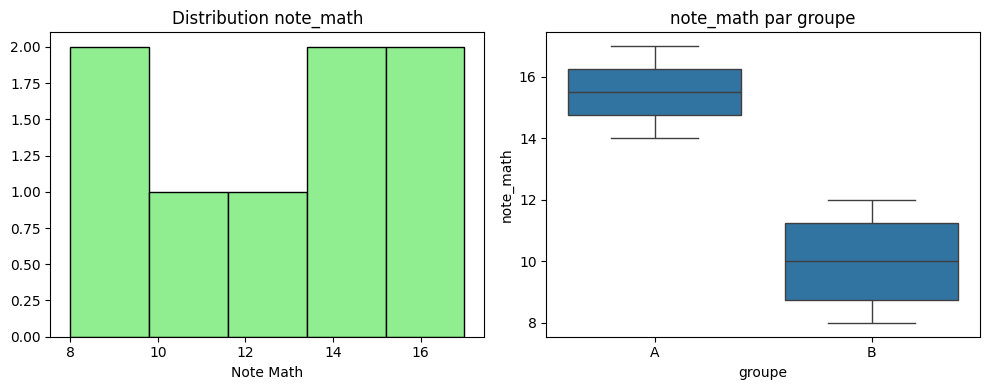

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Histogramme - ax1
ax1.hist(df['note_math'], bins=5, color='lightgreen', edgecolor='black')
ax1.set_xlabel('Note Math')

# Boxplot par groupe - ax2 (seaborn)
sns.boxplot(data=df, x='groupe', y='note_math', ax=ax2)

ax1.set_title('Distribution note_math')
ax2.set_title('note_math par groupe')
plt.tight_layout()
plt.show()


Ressources : [NumPy](https://numpy.org/doc/stable/) · [Pandas](https://pandas.pydata.org/docs/) · [Matplotlib](https://matplotlib.org/stable/) · [Seaborn](https://seaborn.pydata.org/)